# Q4 - Code Review_Required Capstone_12.1

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.stats import norm
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.optimize import minimize

In [2]:
inputs4 = np.array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
       [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
       [0.25094624, 0.03369313, 0.14538002, 0.49493242],
       [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
       [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
       [0.80130271, 0.50023109, 0.70664456, 0.19510284],
       [0.24770826, 0.06044543, 0.04218635, 0.44132425],
       [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
       [0.40066503, 0.07257425, 0.88676825, 0.24384229],
       [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
       [0.95713529, 0.59764438, 0.76611385, 0.77620991],
       [0.73281243, 0.14524998, 0.47681272, 0.13336573],
       [0.65511548, 0.07239183, 0.68715175, 0.08151656],
       [0.21973443, 0.83203134, 0.48286416, 0.08256923],
       [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
       [0.16713049, 0.87655456, 0.21723954, 0.95980098],
       [0.21691119, 0.16608583, 0.24137226, 0.77006248],
       [0.38748784, 0.80453226, 0.75179548, 0.72382744],
       [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
       [0.03782483, 0.66485335, 0.16198218, 0.25392378],
       [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
       [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
       [0.85965692, 0.91959232, 0.20613873, 0.09779683],
       [0.28213837, 0.50598691, 0.53053084, 0.09630162],
       [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
       [0.94838936, 0.89451301, 0.85163782, 0.55219629],
       [0.66495539, 0.04656628, 0.11677747, 0.79371778],
       [0.57776561, 0.42877174, 0.42582587, 0.24900741],
       [0.73861301, 0.48210263, 0.70936644, 0.50397001],
       [0.8548108 , 0.49396462, 0.73530997, 0.80809201],
       [0.371906, 0.372669, 0.232494, 0.457708],
       [0.537357, 0.473759, 0.458170, 0.473568],
       [0.419806, 0.398156, 0.361216, 0.402343]])

In [3]:
outputs4 = np.array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
       -10.06963343, -15.48708254, -12.68168498, -16.02639977,
       -17.04923465, -12.74176599, -27.31639636, -13.52764887,
       -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
       -12.75832422, -19.44155762, -28.90327367, -13.70274694,
       -29.4270914 , -11.56574199, -26.85778644,  -7.96677535,
        -6.70208925, -32.62566022, -19.98949793,  -4.02554228,
       -13.12278233, -23.1394284, -2.705962173757665, -3.760620459832889, 0.5780320575739712])

## Surrogate model

In [45]:
# Replace this with your real hyperparameter samples and outcomes
X = inputs4
# Example black-box response: nonlinear + noise
y = outputs4

# Define a robust kernel
kernel_best_Q4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], nu=2.5,length_scale_bounds=(1e-3, 1e3)) 
#kernel_best_Q4 = ConstantKernel(2.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(1e-3, 1e2)) + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-9, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel_best_Q4,
    n_restarts_optimizer=10,
    alpha=1e-6,
    normalize_y=True)

# Fit GP
gp.fit(X, y)
print("Optimized kernel:", gp.kernel_)


Optimized kernel: 1.5**2 * Matern(length_scale=[0.821, 0.789, 0.734, 0.72], nu=2.5)


## Scatter plot - Observations 

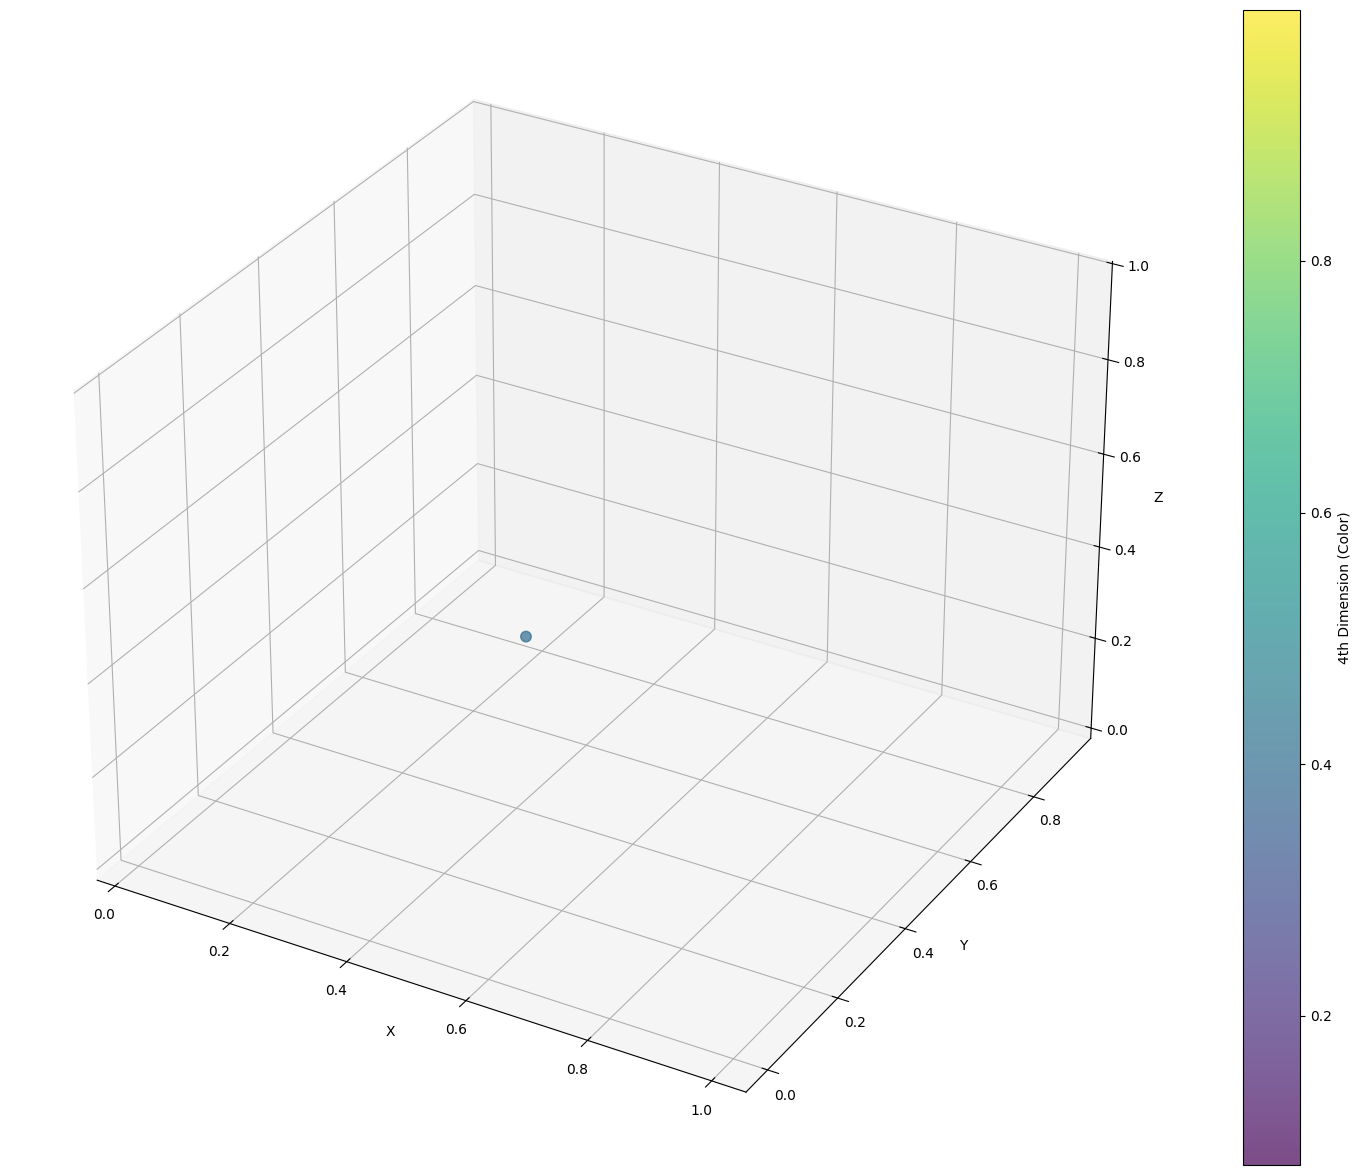

In [6]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X[:, 3], s = y*100, cmap='viridis', alpha=0.7)
# making y negative is for visualiztion purpose
# as -negative size won't show anything

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Acquisition function - Bayesian Optimization (UCB)

In [46]:
def hybrid_ucb(X, gp, kappa=4.0, alpha=0.5):
    """
    Hybrid Upper Confidence Bound (UCB) acquisition function.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Candidate query points.
    gp : GaussianProcessRegressor
        Fitted Gaussian process.
    kappa : float
        Exploration–exploitation tradeoff (larger = more exploration).
    alpha : float
        Balance between pure mean and UCB (0 → pure UCB, 1 → pure mean).
    """
    mu, sigma = gp.predict(X, return_std=True)
    return alpha * mu + (1 - alpha) * (mu + kappa * sigma)


# ----------------------------------------------------
# 2. Global + local optimizer for the acquisition
# ----------------------------------------------------
def optimize_acquisition_global(acquisition_func, gp, bounds, n_random=5000, n_local=10, **kwargs):
    """
    Global + local optimization of acquisition function.
    Works robustly for high-dimensional spaces.

    Parameters
    ----------
    acquisition_func : callable
        Acquisition function (e.g., hybrid_ucb or expected_improvement).
    gp : GaussianProcessRegressor
        Fitted GP model.
    bounds : list of tuples
        Search space bounds [(low, high), ...].
    n_random : int
        Number of random points to explore globally.
    n_local : int
        Number of local refinements from best random points.
    **kwargs : dict
        Extra arguments for the acquisition function.
    """
    dim = len(bounds)

    # Step 1: Random exploration
    X_random = np.random.uniform(
        [b[0] for b in bounds],
        [b[1] for b in bounds],
        size=(n_random, dim)
    )
    y_random = acquisition_func(X_random, gp, **kwargs)

    # Step 2: Choose top n_local points for local refinement
    top_idx = np.argsort(y_random)[-n_local:]
    best_val = -np.inf
    best_x = None

    # Step 3: Local optimization (L-BFGS-B) from multiple starts
    for idx in top_idx:
        x0 = X_random[idx]

        def objective(x):
            return -acquisition_func(x.reshape(1, -1), gp, **kwargs)

        res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
        if not res.success:
            continue

        val = -res.fun
        if val > best_val:
            best_val = val
            best_x = res.x

    return best_x

In [47]:
bounds = [(0, 1), (0, 1), (0, 1), (0 ,1)]

# Optimize acquisition
next_point = optimize_acquisition_global(hybrid_ucb, gp, bounds, n_random=8000, n_local=15, kappa=3.0, alpha=0.5)

# Transform back to [0, 1]^3

print("Next query point (by UCB):", next_point)

Next query point (by UCB): [0.31615494 0.41409491 0.42253772 0.38503916]


## Acquisition function - Bayesian Optimization (EI)

In [48]:
# Expected Improvement acquisition function
def expected_improvement(X, gp, y_best, xi=0.01):
    """
    Compute Expected Improvement at points X.
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Candidate points.
    gp : fitted GaussianProcessRegressor
        Trained GP model.
    y_best : float
        Best (maximum) observed target value so far.
    xi : float
        Exploration parameter (higher = more exploration).
    
    Returns
    -------
    EI : np.ndarray
        Expected improvement values at each point.
    """
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid divide-by-zero
    
    Z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0  # EI is zero where uncertainty is zero
    return ei


# ------------------------------
# Optimize acquisition globally (using Differential Evolution)
# ------------------------------
def optimize_acquisition_global_ei(acquisition_func, gp, bounds, y_best, xi=0.01, maxiter=100, popsize=15):
    """
    Global optimization of acquisition function (EI) using Differential Evolution.
    
    Parameters
    ----------
    acquisition_func : callable
        The acquisition function, e.g. expected_improvement.
    gp : fitted GaussianProcessRegressor
        Trained GP model.
    bounds : list of tuples
        Search space bounds [(x1_min, x1_max), ...].
    y_best : float
        Best observed function value so far.
    xi : float
        Exploration-exploitation parameter for EI.
    maxiter, popsize : int
        Parameters for the DE optimizer.
    
    Returns
    -------
    x_next : np.ndarray
        Next query point.
    best_val : float
        Acquisition function value at x_next.
    """
    def objective1(x):
        x = np.array(x).reshape(1, -1)
        return -acquisition_func(x, gp=gp, y_best=y_best, xi=xi)[0]

    result = differential_evolution(
        objective1,
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        polish=True,
        disp=True
    )

    x_next = result.x
    best_val = -result.fun
    return x_next, best_val    

In [50]:
bounds = [(0, 1), (0, 1), (0, 1),(0, 1)]

y_best = np.max(y)

next_point1, best_val = optimize_acquisition_global_ei(
        acquisition_func=expected_improvement,
        gp=gp,
        bounds=bounds,
        y_best=y_best,
        xi=1,     # increase xi for more exploration
        maxiter=8000,
        popsize=15
    )

print("\nNext query point (by global EI):", next_point1)
print("EI value at that point:", best_val)


differential_evolution step 1: f(x)= -0.008791680995540535
differential_evolution step 2: f(x)= -0.008791680995540535
differential_evolution step 3: f(x)= -0.017607080386952703
differential_evolution step 4: f(x)= -0.017607080386952703
differential_evolution step 5: f(x)= -0.02446720065948574
differential_evolution step 6: f(x)= -0.034462677827411525
differential_evolution step 7: f(x)= -0.03468566007368598
differential_evolution step 8: f(x)= -0.0353766343002965
differential_evolution step 9: f(x)= -0.050299508022703304
differential_evolution step 10: f(x)= -0.050299508022703304
differential_evolution step 11: f(x)= -0.05569991211326869
differential_evolution step 12: f(x)= -0.05664503543758889
differential_evolution step 13: f(x)= -0.05664503543758889
differential_evolution step 14: f(x)= -0.058406436562937536
differential_evolution step 15: f(x)= -0.058406436562937536
differential_evolution step 16: f(x)= -0.058406436562937536
differential_evolution step 17: f(x)= -0.058406436562937

## Predicted mean and standrd deviation

In [51]:
x1 = np.linspace(0, 1, 20)
x2 = np.linspace(0, 1, 20)
x3 = np.linspace(0, 1, 20)
x4 = np.linspace(0, 1, 20)
X1, X2, X3, X4 = np.meshgrid(x1, x2, x3, x4)
X_grid = np.column_stack([X1.ravel(), X2.ravel(), X3.ravel(), X4.ravel()])

y_mean, y_std = gp.predict(X_grid, return_std=True)

## Visualization - Predicted Mean

C:\Users\kanki\anaconda3\lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


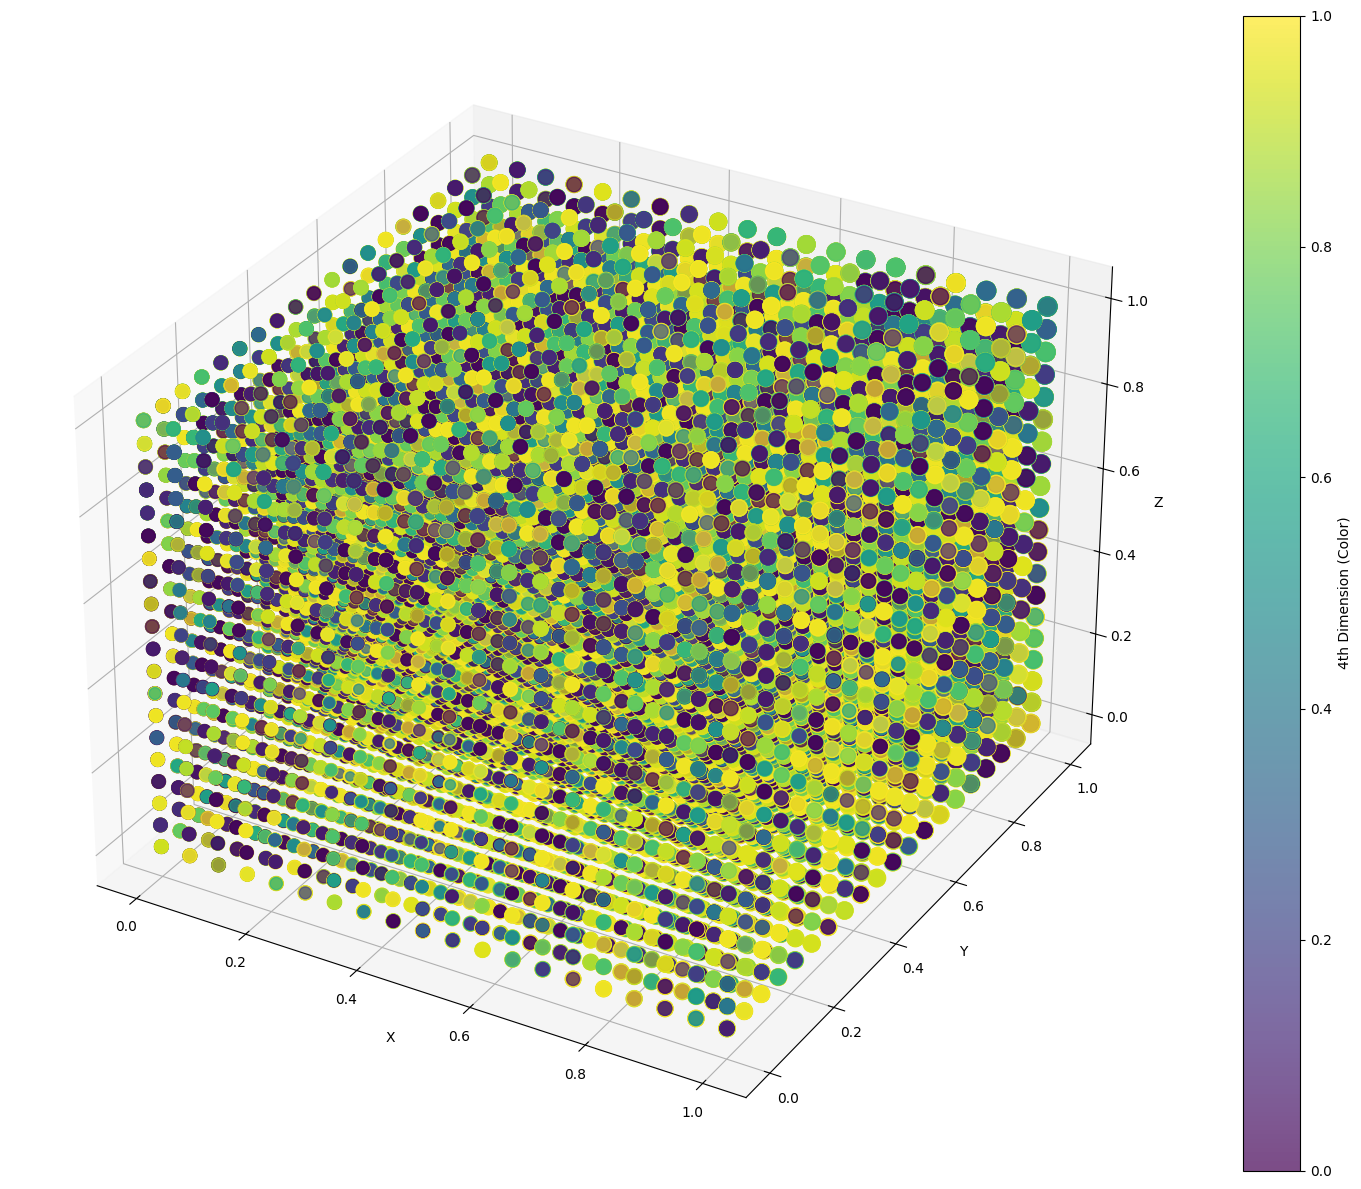

In [52]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_grid[:, 0], X_grid[:, 1], X_grid[:, 2], c=X_grid[:, 3], s = -y_mean*5, cmap='viridis', alpha=0.7)
ax.scatter(next_point[0], next_point[1], next_point[2], c="red", s=1000, marker="*", label="Next query")
#because output is difference from the baseline and the problem is related to cost saving (i.e. deduction from baseline)
#so, output is negative
#to visualize the output, adding a negative to output is needed

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Visualization - Predicted standard deviation

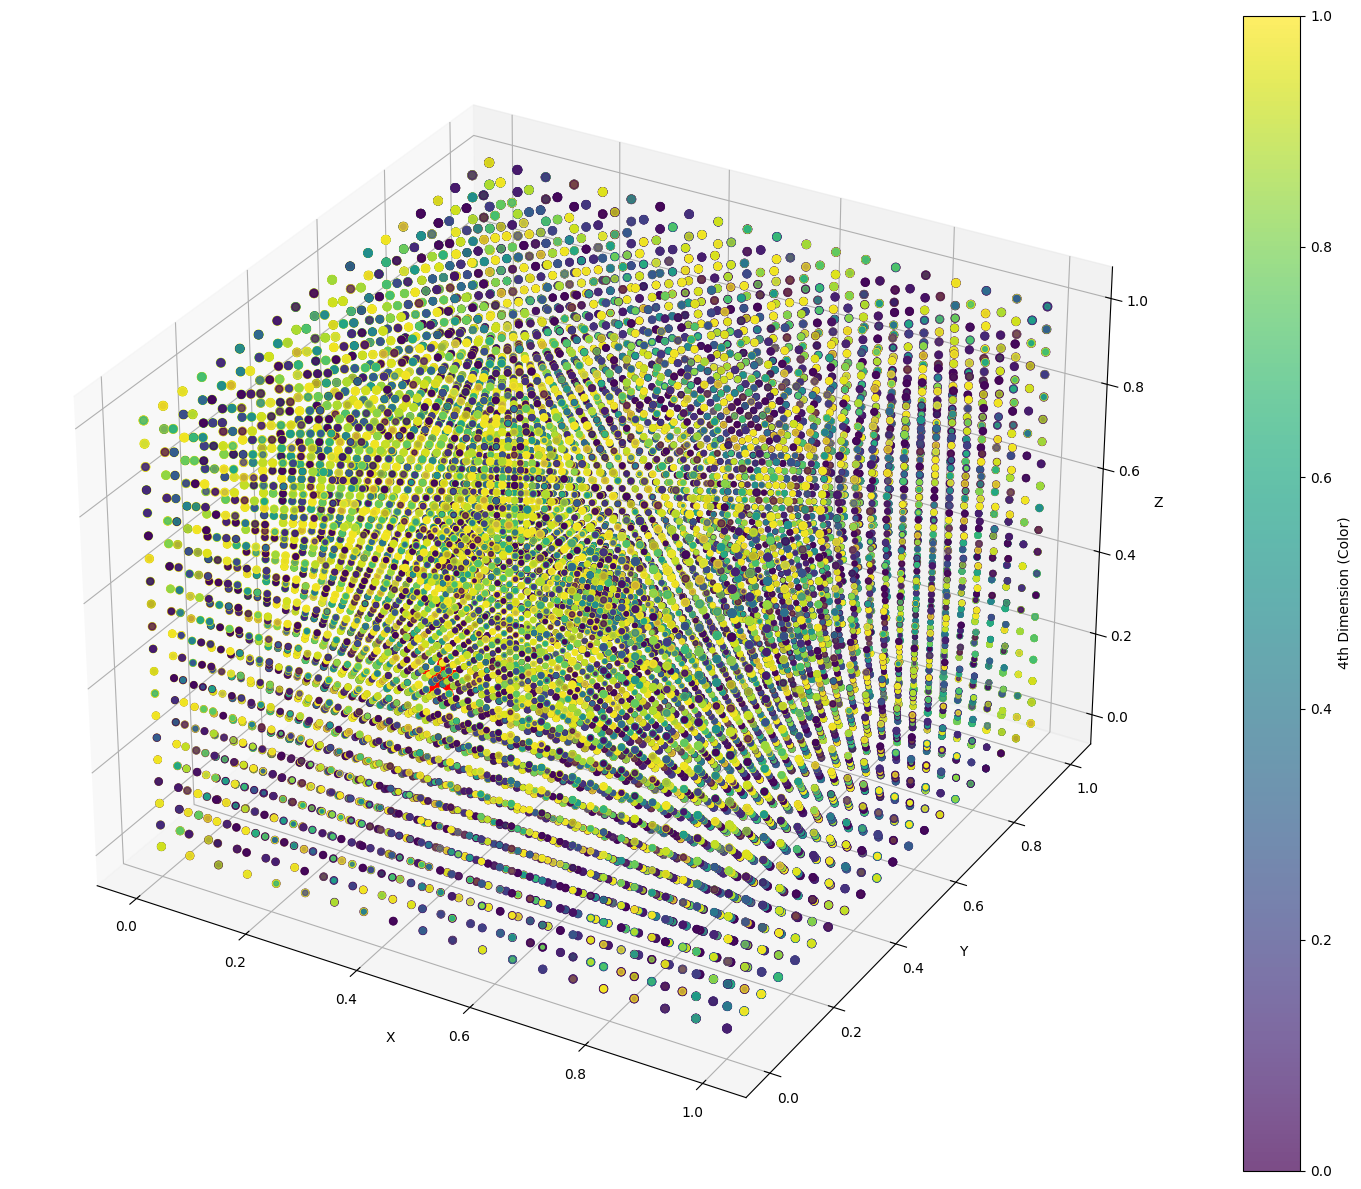

In [53]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_grid[:, 0], X_grid[:, 1], X_grid[:, 2], c=X_grid[:, 3], s = y_std*5, cmap='viridis', alpha=0.7)
ax.scatter(next_point[0], next_point[0], next_point[0], c="red", s=1000, marker="*", label="Next query")
#because output is difference from the baseline and the problem is related to cost saving (i.e. deduction from baseline)
#so, output is negative
#to visualize the output, adding a negative to output is needed

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()